# Modelling total shots a team takes


## Modelling a probability distribution

To model the total number of shots taken, we can separately model expected home shots vs expected away shots.

We can start off by using a linear regression just to understand basic relationships, actually use Poisson/Neg Bin to model the shots, Try using tree based model to see how much we are leaving out.

### Shots can be dependant on
- odds of the team winning/drawing/losing (Probably cannot add all three due to collinearity, but can add any two)
- An adjusted indicator matric of the rolling average of the number of shots the team took based on if they were home or away and how strong their opponents were
- League (might include it, but not sure for now)

### Different questions to test out in modelling

- How does the model do with a linear regression/poisson distribution/tree model
- If we need a league/season/both terms or not
- See which two odds I should add
- Potentially work with different types of adjusted rolling shots
- See if past variance in shots can influence our model

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

### Data

We can start off with a dataset of all matches: Can add Premier League, Serie A, Bundesliga, La Liga past 5 seasons each.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/shots_odds/Model_2/football_data.csv')

Mounted at /content/drive


In [3]:
data

,Unnamed: 0,date,home_team,away_team,home_shots,away_shots,odds_h,odds_d,odds_a,league,season,prob_h,prob_d,prob_a
0,0,2019-08-09,Liverpool,Norwich,15.0,12.0,1.16,10.00,23.00,premier_league,1920,0.857313,0.099448,0.043238
1,1,2019-08-10,West Ham,Man City,5.0,14.0,13.00,6.75,1.29,premier_league,1920,0.076903,0.148109,0.774988
2,2,2019-08-10,Bournemouth,Sheffield United,13.0,8.0,2.06,3.65,4.00,premier_league,1920,0.480912,0.271419,0.247670
3,3,2019-08-10,Burnley,Southampton,10.0,11.0,2.80,3.33,2.85,premier_league,1920,0.354196,0.297822,0.347982
4,4,2019-08-10,Crystal Palace,Everton,6.0,10.0,3.21,3.40,2.52,premier_league,1920,0.310759,0.293393,0.395848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8670,8671,2025-05-25,Empoli,Verona,14.0,5.0,2.04,3.40,4.35,serie_a,2425,0.483333,0.290000,0.226667
8671,8672,2025-05-25,Lazio,Lecce,26.0,9.0,1.64,3.86,8.00,serie_a,2425,0.613546,0.260677,0.125777
8672,8673,2025-05-25,Torino,Roma,11.0,15.0,6.33,4.33,1.60,serie_a,2425,0.155808,0.227775,0.616417
8673,8674,2025-05-25,Udinese,Fiorentina,12.0,25.0,3.81,3.75,2.06,serie_a,2425,0.258698,0.262837,0.478465


### Create columns for Adjusted shots

- Adjusted shots H/A
- Adjusted shots conceded H/A

I am working on the adjusted shots, for which I will need to figure out how to adjust for H/A and strength of opponent.

# Adjusted Shots Feature Engineering

#### Step 1 — Venue Neutralisation
For each game in a team's rolling window, we adjust the raw shot count to a neutral baseline using the league-season expanding average:

- If the team was **at home**: subtract the home premium
- If the team was **away**: add the away discount

$$\text{NeutralShots} = \text{RawShots} - (\text{ExpandingAvgHomeShots} - \text{ExpandingNeutral}) \quad \text{if home}$$
$$\text{NeutralShots} = \text{RawShots} + (\text{ExpandingNeutral} - \text{ExpandingAvgAwayShots}) \quad \text{if away}$$

The neutral baseline is computed as an **expanding average within the current season only**, using only games played prior to the current match to avoid lookahead bias.

#### Step 2 — Opponent Strength Adjustment
We then scale the neutral shots by how difficult the opponent was to generate shots against:

$$\text{AdjShots} = \text{NeutralShots} \times \frac{\text{LeagueSeasonExpandingAvgShotsConc}}{\text{OpponentRollingAvgShotsConc}}$$

- A strong defensive opponent (low shots conceded) scales the value **up**
- A weak defensive opponent (high shots conceded) scales the value **down**

The opponent's defensive strength is their rolling average shots conceded over their last 5 games in the current season.

#### Step 3 — Rolling Average
Finally, we take the **rolling mean of the last 5 adjusted shots values** within the current season:

$$\text{RollingAdjShots} = \frac{1}{N}\sum_{i=1}^{N} \text{AdjShots}_i \quad N \in [3, 5]$$

#### Rules
- **Same season only** — rolling window never crosses a season boundary
- **Minimum 3 games** — fewer than 3 prior games in the season returns NaN
- **No lookahead** — all averages use only information available before the match
- **Computed separately** for shots scored and shots conceded, for both home and away teams, yielding 4 features per match:
  - `home_adj_shots` — home team's adjusted attacking output
  - `home_adj_shots_conc` — home team's adjusted defensive softness
  - `away_adj_shots` — away team's adjusted attacking output
  - `away_adj_shots_conc` — away team's adjusted defensive softness

#### Check for shots throughout the seasons

I want to see how total average shots per match, home shots per match and away shots per match differ across seasons and leagues

In [4]:
data['total_shots'] = data['home_shots'] + data['away_shots']

In [5]:
league_season_avg = (data.groupby(['league', 'season'])['total_shots']
                     .mean()
                     .reset_index()
                     .rename(columns={'total_shots': 'avg_total_shots'}))

print(league_season_avg)

            league  season  avg_total_shots
0       bundesliga    1920        26.529412
1       bundesliga    2021        24.650327
2       bundesliga    2122        25.718954
3       bundesliga    2223        25.287582
4       bundesliga    2324        27.179739
5       bundesliga    2425        25.796721
6          la_liga    1920        22.600000
7          la_liga    2021        21.347368
8          la_liga    2122        23.550000
9          la_liga    2223        24.623684
10         la_liga    2324        24.463158
11         la_liga    2425        23.692105
12  premier_league    1920        24.723684
13  premier_league    2021        24.178947
14  premier_league    2122        25.584211
15  premier_league    2223        25.263158
16  premier_league    2324        27.584211
17  premier_league    2425        25.918421
18         serie_a    1920        21.147368
19         serie_a    2021        21.902632
20         serie_a    2122        25.881579
21         serie_a    2223      

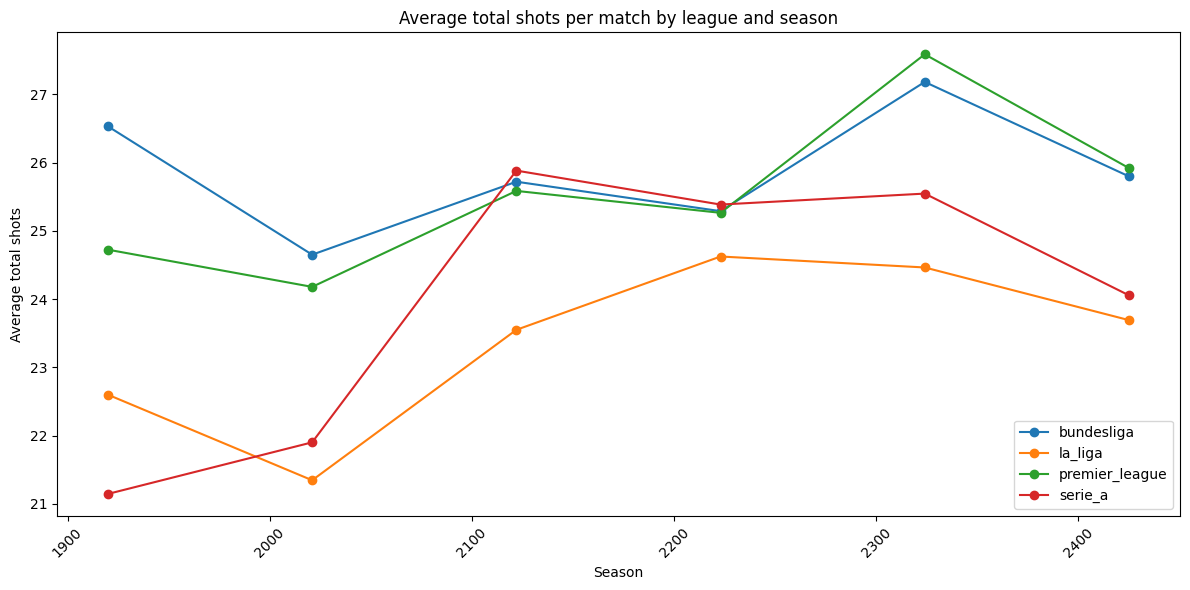

In [6]:
leagues = league_season_avg['league'].unique()

plt.figure(figsize=(12, 6))

for league in leagues:
    subset = league_season_avg[league_season_avg['league'] == league]
    plt.plot(subset['season'], subset['avg_total_shots'], marker='o', label=league)

plt.title('Average total shots per match by league and season')
plt.xlabel('Season')
plt.ylabel('Average total shots')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

What this graph shows us is we have to take into account both season and league, so we prepared the data on this basis

In [7]:
from google.colab import drive
drive.mount('/content/drive')

data_2 = pd.read_csv('/content/drive/MyDrive/shots_odds/Model_2/football_data_adjcols.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Linear Regression


In [8]:
# To start the regression, lets first split the dataset into 4 different components: X_home, Y_home, X_away, Y_away

Y_home = data_2['home_shots']
Y_away = data_2['away_shots']

X_home = data_2[['league','prob_h','prob_d','home_adj_shots','away_adj_shots_conc']]
X_away = data_2[['league','prob_d','prob_a','away_adj_shots','home_adj_shots_conc']]

X_home = pd.get_dummies(X_home, columns=['league'], drop_first=True)
X_away = pd.get_dummies(X_away, columns=['league'], drop_first=True)

In [9]:
# 1. Sort by date to ensure temporal order
data_2 = data_2.sort_values('date').reset_index(drop=True)

# ── Hyperparameters ─────────────────────────────────────────
RETRAIN_EVERY = 100   # retrain every N rows
MIN_TRAIN_SIZE = 2000 # minimum rows before first prediction
# ────────────────────────────────────────────────────────────

In [10]:
# 2. Get feature column names after dummy encoding
feature_cols_home = X_home.columns.tolist()
feature_cols_away = X_away.columns.tolist()

print("Home features:", feature_cols_home)
print("Away features:", feature_cols_away)

Home features: ['prob_h', 'prob_d', 'home_adj_shots', 'away_adj_shots_conc', 'league_la_liga', 'league_premier_league', 'league_serie_a']
Away features: ['prob_d', 'prob_a', 'away_adj_shots', 'home_adj_shots_conc', 'league_la_liga', 'league_premier_league', 'league_serie_a']


In [11]:
from sklearn.linear_model import LinearRegression

results = []
home_model = LinearRegression()
away_model = LinearRegression()

for i in range(MIN_TRAIN_SIZE, len(data_2)):

    # Retrain every RETRAIN_EVERY rows
    if (i - MIN_TRAIN_SIZE) % RETRAIN_EVERY == 0:
        X_home_train = X_home.iloc[:i]
        X_away_train = X_away.iloc[:i]
        Y_home_train = Y_home.iloc[:i]
        Y_away_train = Y_away.iloc[:i]

        home_model.fit(X_home_train, Y_home_train)
        away_model.fit(X_away_train, Y_away_train)

    # Predict current row
    pred_home  = home_model.predict(X_home.iloc[[i]])[0]
    pred_away  = away_model.predict(X_away.iloc[[i]])[0]
    pred_total = pred_home + pred_away

    actual_home  = Y_home.iloc[i]
    actual_away  = Y_away.iloc[i]
    actual_total = actual_home + actual_away

    results.append({
        'date':         data_2['date'].iloc[i],
        'home_team':    data_2['home_team'].iloc[i],
        'away_team':    data_2['away_team'].iloc[i],
        'pred_home':    pred_home,
        'pred_away':    pred_away,
        'pred_total':   pred_total,
        'actual_home':  actual_home,
        'actual_away':  actual_away,
        'actual_total': actual_total
    })

results_df = pd.DataFrame(results)
print(f"Total predictions: {len(results_df)}")
print(results_df.head())

Total predictions: 5258
         date home_team   away_team  pred_home  pred_away  pred_total  \
0  2021-03-14    Torino       Inter  13.312588  11.386183   24.698771   
1  2021-03-14   Arsenal   Tottenham  14.267590  12.857314   27.124904   
2  2021-03-14     Celta  Ath Bilbao  17.792574   8.752716   26.545290   
3  2021-03-14   Granada    Sociedad  16.799645   9.774262   26.573906   
4  2021-03-14     Eibar  Villarreal   9.110776  19.903831   29.014608   

   actual_home  actual_away  actual_total  
0         14.0         12.0          26.0  
1         16.0          7.0          23.0  
2         17.0         10.0          27.0  
3         17.0         21.0          38.0  
4         15.0         22.0          37.0  


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("HOME SHOTS")
print(f"RMSE: {np.sqrt(mean_squared_error(results_df['actual_home'], results_df['pred_home'])):.3f}")
print(f"MAE:  {mean_absolute_error(results_df['actual_home'], results_df['pred_home']):.3f}")
print(f"R²:   {r2_score(results_df['actual_home'], results_df['pred_home']):.3f}")

print("\nAWAY SHOTS")
print(f"RMSE: {np.sqrt(mean_squared_error(results_df['actual_away'], results_df['pred_away'])):.3f}")
print(f"MAE:  {mean_absolute_error(results_df['actual_away'], results_df['pred_away']):.3f}")
print(f"R²:   {r2_score(results_df['actual_away'], results_df['pred_away']):.3f}")

print("\nTOTAL SHOTS")
print(f"RMSE: {np.sqrt(mean_squared_error(results_df['actual_total'], results_df['pred_total'])):.3f}")
print(f"MAE:  {mean_absolute_error(results_df['actual_total'], results_df['pred_total']):.3f}")
print(f"R²:   {r2_score(results_df['actual_total'], results_df['pred_total']):.3f}")

HOME SHOTS
RMSE: 4.564
MAE:  3.548
R²:   0.234

AWAY SHOTS
RMSE: 4.129
MAE:  3.241
R²:   0.204

TOTAL SHOTS
RMSE: 5.634
MAE:  4.445
R²:   0.115


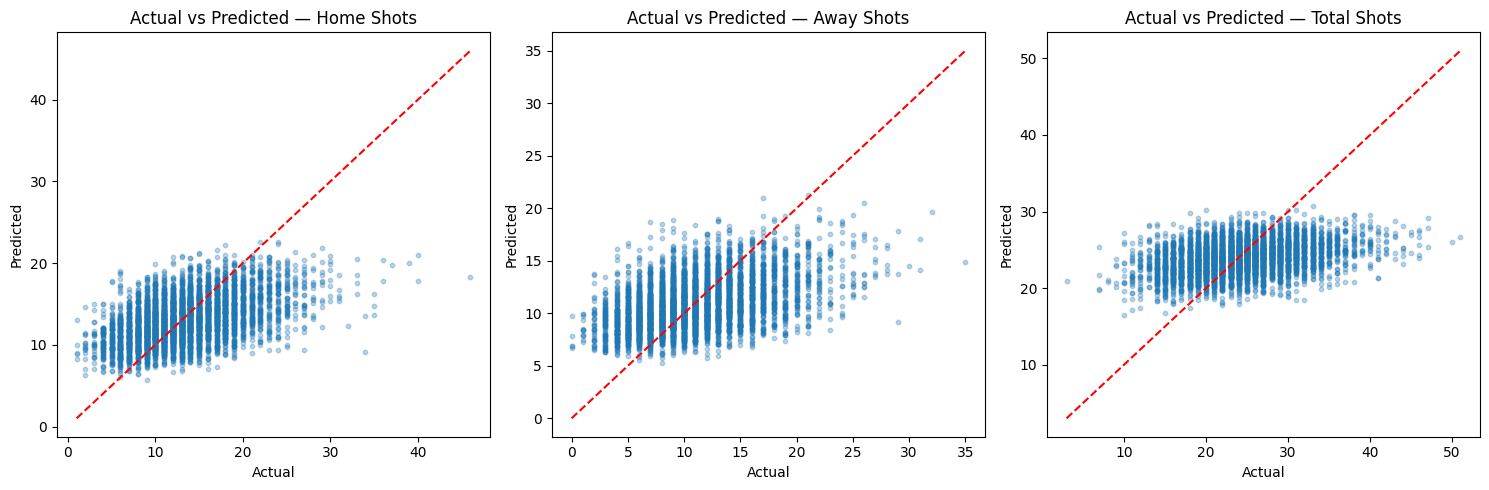

In [13]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pred_col, actual_col, title in zip(
    axes,
    ['pred_home', 'pred_away', 'pred_total'],
    ['actual_home', 'actual_away', 'actual_total'],
    ['Home Shots', 'Away Shots', 'Total Shots']
):
    ax.scatter(results_df[actual_col], results_df[pred_col], alpha=0.3, s=10)
    min_val = min(results_df[actual_col].min(), results_df[pred_col].min())
    max_val = max(results_df[actual_col].max(), results_df[pred_col].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'Actual vs Predicted — {title}')

plt.tight_layout()
plt.show()

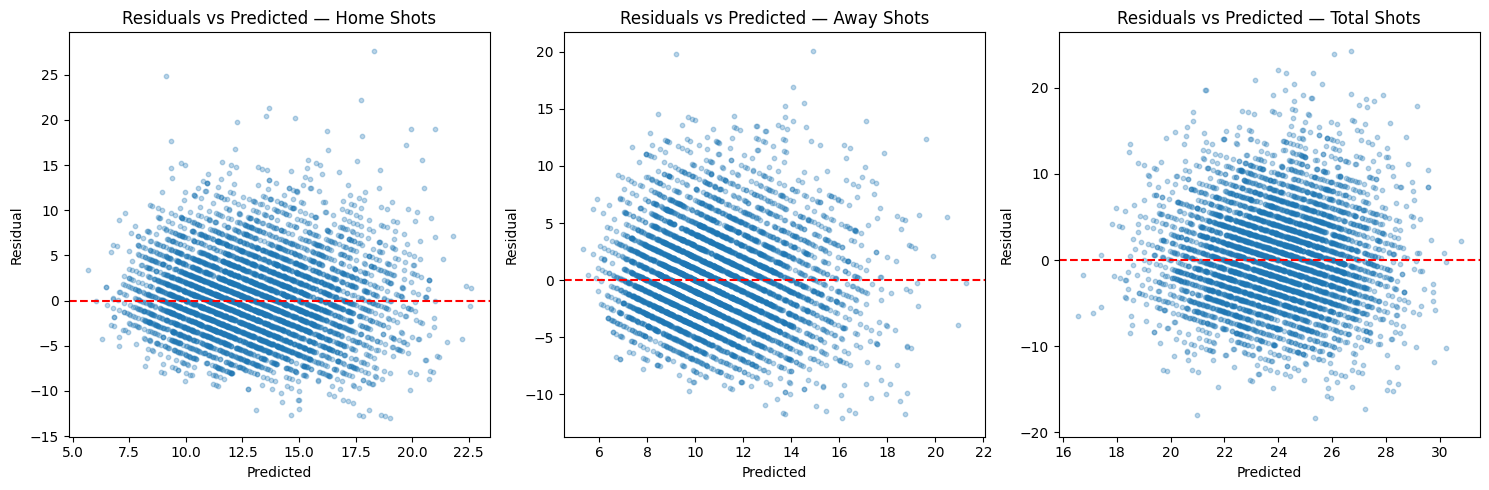

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pred_col, actual_col, title in zip(
    axes,
    ['pred_home', 'pred_away', 'pred_total'],
    ['actual_home', 'actual_away', 'actual_total'],
    ['Home Shots', 'Away Shots', 'Total Shots']
):
    residuals = results_df[actual_col] - results_df[pred_col]
    ax.scatter(results_df[pred_col], residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(f'Residuals vs Predicted — {title}')

plt.tight_layout()
plt.show()

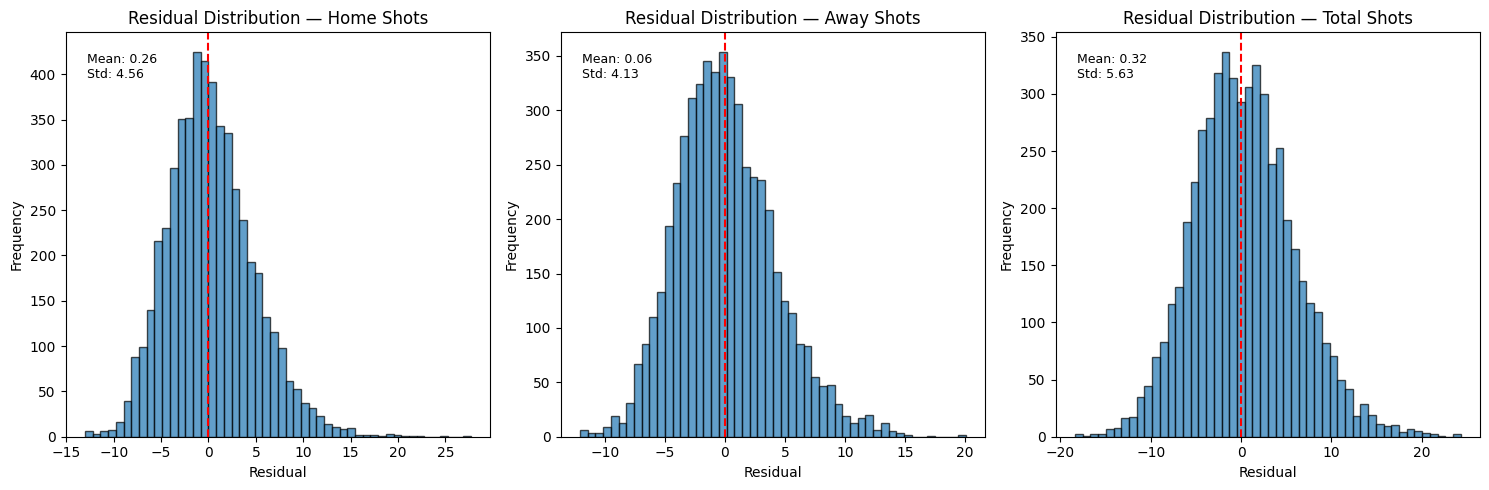

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pred_col, actual_col, title in zip(
    axes,
    ['pred_home', 'pred_away', 'pred_total'],
    ['actual_home', 'actual_away', 'actual_total'],
    ['Home Shots', 'Away Shots', 'Total Shots']
):
    residuals = results_df[actual_col] - results_df[pred_col]
    ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='r', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Residual Distribution — {title}')
    ax.annotate(f'Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}',
                xy=(0.05, 0.95), xycoords='axes fraction',
                va='top', fontsize=9)

plt.tight_layout()
plt.show()

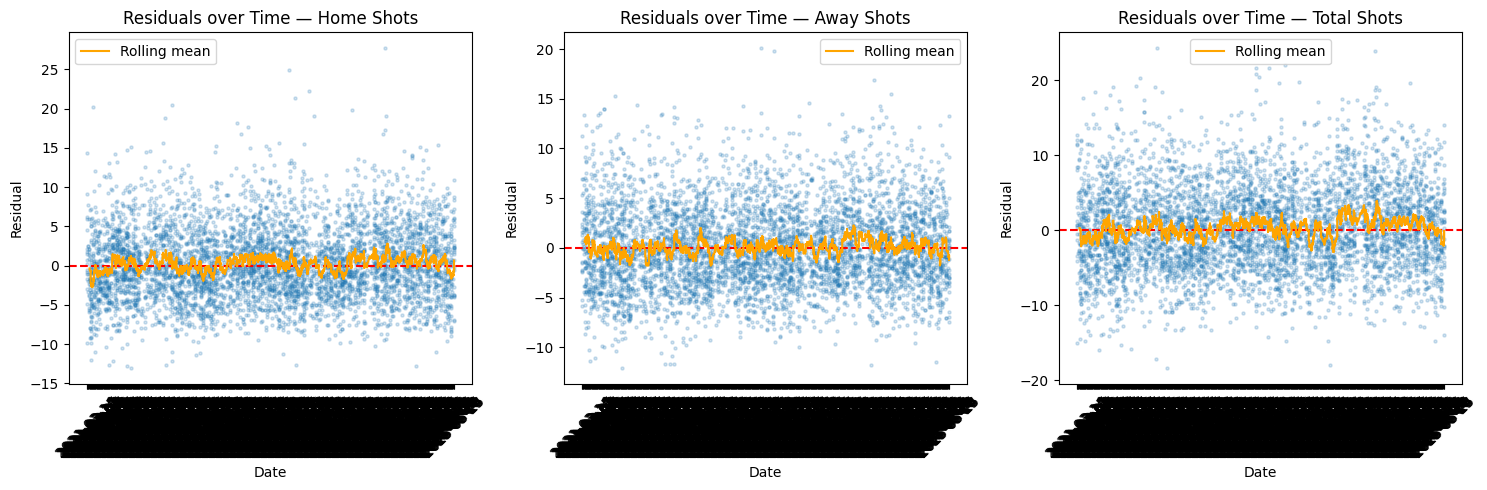

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pred_col, actual_col, title in zip(
    axes,
    ['pred_home', 'pred_away', 'pred_total'],
    ['actual_home', 'actual_away', 'actual_total'],
    ['Home Shots', 'Away Shots', 'Total Shots']
):
    residuals = results_df[actual_col] - results_df[pred_col]
    ax.scatter(results_df['date'], residuals, alpha=0.2, s=5)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
    # Rolling mean of residuals to show trend
    rolling_resid = residuals.rolling(window=50).mean()
    ax.plot(results_df['date'], rolling_resid, color='orange', linewidth=1.5, label='Rolling mean')
    ax.set_xlabel('Date')
    ax.set_ylabel('Residual')
    ax.set_title(f'Residuals over Time — {title}')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_10577/2202324426.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],
/tmp/ipykernel_10577/2202324426.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],
/tmp/ipykernel_10577/2202324426.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],


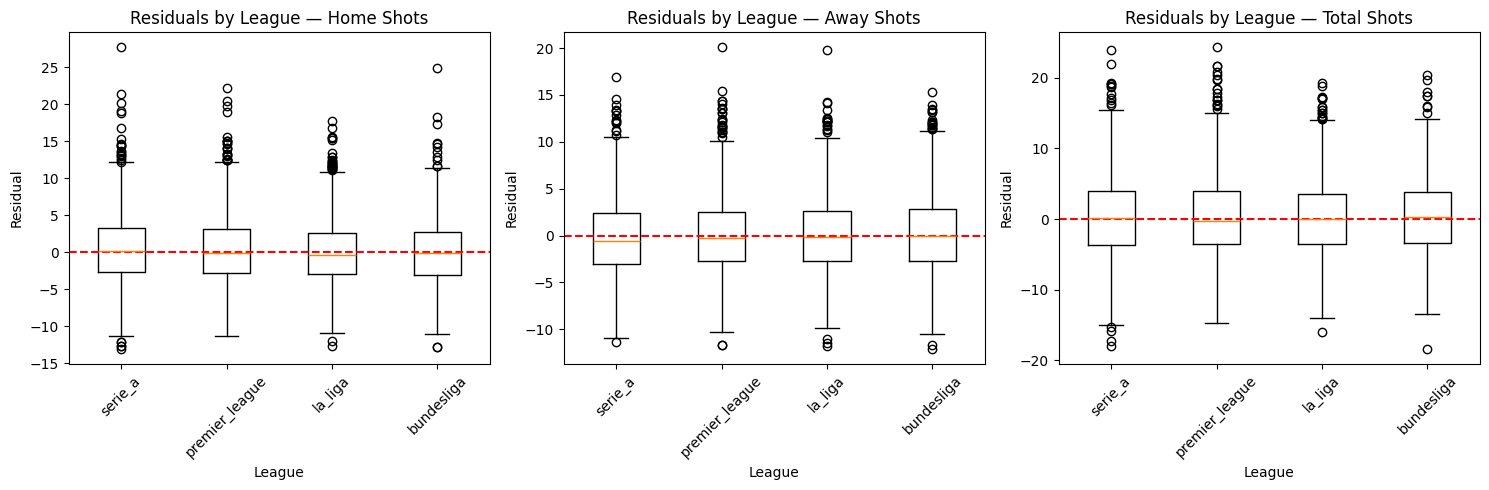

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pred_col, actual_col, title in zip(
    axes,
    ['pred_home', 'pred_away', 'pred_total'],
    ['actual_home', 'actual_away', 'actual_total'],
    ['Home Shots', 'Away Shots', 'Total Shots']
):
    residuals = results_df[actual_col] - results_df[pred_col]
    plot_df = pd.DataFrame({
        'residual': residuals,
        'league': data_2.iloc[MIN_TRAIN_SIZE:].reset_index(drop=True)['league']
    })
    leagues = plot_df['league'].unique()
    ax.boxplot([plot_df[plot_df['league'] == l]['residual'] for l in leagues],
               labels=leagues)
    ax.axhline(y=0, color='r', linestyle='--', linewidth=1.5)
    ax.set_xlabel('League')
    ax.set_ylabel('Residual')
    ax.set_title(f'Residuals by League — {title}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

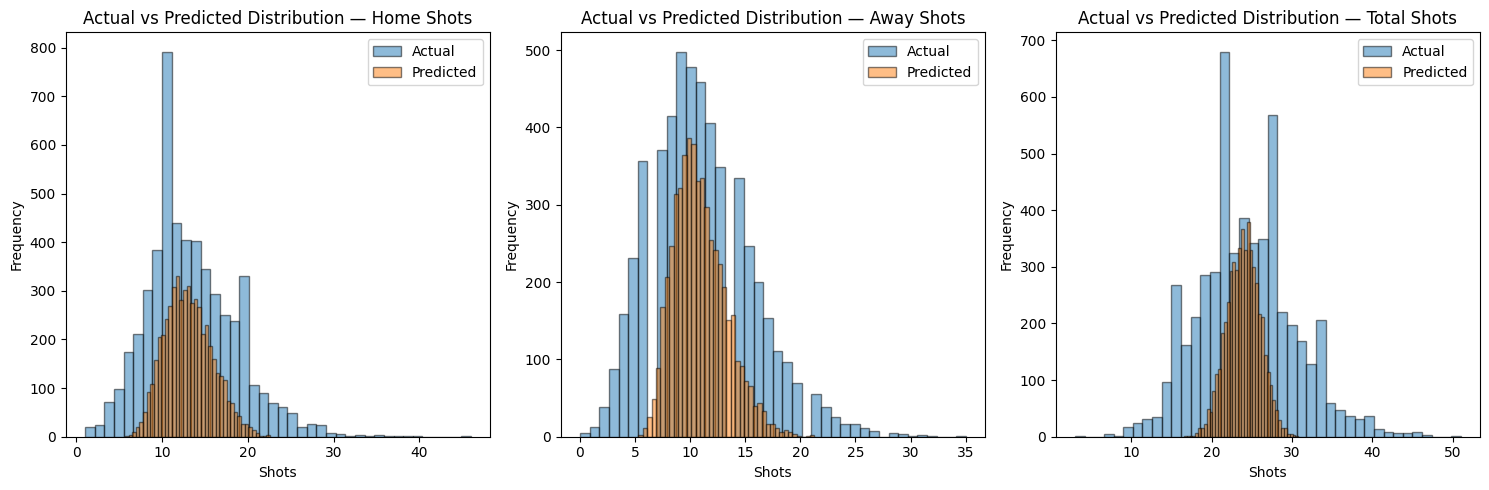

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pred_col, actual_col, title in zip(
    axes,
    ['pred_home', 'pred_away', 'pred_total'],
    ['actual_home', 'actual_away', 'actual_total'],
    ['Home Shots', 'Away Shots', 'Total Shots']
):
    ax.hist(results_df[actual_col], bins=40, alpha=0.5, label='Actual', edgecolor='black')
    ax.hist(results_df[pred_col],   bins=40, alpha=0.5, label='Predicted', edgecolor='black')
    ax.set_xlabel('Shots')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Actual vs Predicted Distribution — {title}')
    ax.legend()

plt.tight_layout()
plt.show()

### F tests to check if the model is any good and check against League

Test to check model against a baseline intercept benchmark

In [21]:
import statsmodels.api as sm

X_home = X_home.astype(float)
X_away = X_away.astype(float)

# Use only the initial training window — consistent with walk-forward approach
X_home_train_sm = sm.add_constant(X_home.iloc[:MIN_TRAIN_SIZE])
X_away_train_sm = sm.add_constant(X_away.iloc[:MIN_TRAIN_SIZE])

Y_home_train_sm = Y_home.iloc[:MIN_TRAIN_SIZE]
Y_away_train_sm = Y_away.iloc[:MIN_TRAIN_SIZE]

home_model_sm = sm.OLS(Y_home_train_sm, X_home_train_sm).fit()
away_model_sm = sm.OLS(Y_away_train_sm, X_away_train_sm).fit()

print("HOME MODEL")
print(home_model_sm.summary())

print("\nAWAY MODEL")
print(away_model_sm.summary())

HOME MODEL
                            OLS Regression Results                            
Dep. Variable:             home_shots   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.325
Method:                 Least Squares   F-statistic:                     193.1
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.66e-168
Time:                        15:43:13   Log-Likelihood:                -5928.6
No. Observations:                2000   AIC:                         1.187e+04
Df Residuals:                    1994   BIC:                         1.190e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const              

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


test to check if it makes sense to keep league

In [23]:
# Model without league
X_home_no_league = X_home.iloc[:MIN_TRAIN_SIZE].drop(columns=[c for c in X_home.columns if 'league' in c])
X_away_no_league = X_away.iloc[:MIN_TRAIN_SIZE].drop(columns=[c for c in X_away.columns if 'league' in c])

X_home_no_league_sm = sm.add_constant(X_home_no_league.astype(float))
X_away_no_league_sm = sm.add_constant(X_away_no_league.astype(float))

home_model_no_league = sm.OLS(Y_home.iloc[:MIN_TRAIN_SIZE], X_home_no_league_sm).fit()
away_model_no_league = sm.OLS(Y_away.iloc[:MIN_TRAIN_SIZE], X_away_no_league_sm).fit()

In [27]:
# Partial F-test — does league significantly improve the model?
def partial_f_test(full_model, reduced_model, n_restrictions):
    RSS_full    = full_model.ssr
    RSS_reduced = reduced_model.ssr
    df_full     = full_model.df_resid

    F_stat  = ((RSS_reduced - RSS_full) / n_restrictions) / (RSS_full / df_full)
    p_value = 1 - stats.f.cdf(F_stat, n_restrictions, df_full)
    return F_stat, p_value

n_league_dummies = len([c for c in X_home.columns if 'league' in c])

F_home, p_home = partial_f_test(home_model_sm, home_model_no_league, n_league_dummies)
F_away, p_away = partial_f_test(away_model_sm, away_model_no_league, n_league_dummies)

print(f"HOME MODEL — Partial F-test for league")
print(f"F-statistic: {F_home:.4f}")
print(f"P-value:     {p_home:.6f}")

print(f"\nAWAY MODEL — Partial F-test for league")
print(f"F-statistic: {F_away:.4f}")
print(f"P-value:     {p_away:.6f}")

HOME MODEL — Partial F-test for league
F-statistic: 0.8802
P-value:     0.450613

AWAY MODEL — Partial F-test for league
F-statistic: 0.0005
P-value:     0.999984


In [28]:
# Side by side comparison of both models
print("HOME MODEL COMPARISON")
print(f"{'Metric':<20} {'With League':>15} {'Without League':>15}")
print("-" * 52)
print(f"{'R²':<20} {home_model_sm.rsquared:>15.4f} {home_model_no_league.rsquared:>15.4f}")
print(f"{'Adj R²':<20} {home_model_sm.rsquared_adj:>15.4f} {home_model_no_league.rsquared_adj:>15.4f}")
print(f"{'AIC':<20} {home_model_sm.aic:>15.2f} {home_model_no_league.aic:>15.2f}")
print(f"{'BIC':<20} {home_model_sm.bic:>15.2f} {home_model_no_league.bic:>15.2f}")
print(f"{'F-statistic':<20} {home_model_sm.fvalue:>15.4f} {home_model_no_league.fvalue:>15.4f}")

print("\nAWAY MODEL COMPARISON")
print(f"{'Metric':<20} {'With League':>15} {'Without League':>15}")
print("-" * 52)
print(f"{'R²':<20} {away_model_sm.rsquared:>15.4f} {away_model_no_league.rsquared:>15.4f}")
print(f"{'Adj R²':<20} {away_model_sm.rsquared_adj:>15.4f} {away_model_no_league.rsquared_adj:>15.4f}")
print(f"{'AIC':<20} {away_model_sm.aic:>15.2f} {away_model_no_league.aic:>15.2f}")
print(f"{'BIC':<20} {away_model_sm.bic:>15.2f} {away_model_no_league.bic:>15.2f}")
print(f"{'F-statistic':<20} {away_model_sm.fvalue:>15.4f} {away_model_no_league.fvalue:>15.4f}")

HOME MODEL COMPARISON
Metric                   With League  Without League
----------------------------------------------------
R²                            0.3262          0.3253
Adj R²                        0.3245          0.3240
AIC                         11869.16        11869.81
BIC                         11902.77        11897.81
F-statistic                 193.1000        240.5170

AWAY MODEL COMPARISON
Metric                   With League  Without League
----------------------------------------------------
R²                            0.3001          0.3001
Adj R²                        0.2984          0.2987
AIC                         11549.89        11547.89
BIC                         11583.50        11575.90
F-statistic                 171.0175        213.8785


The model is better without league variable.

test to check if we should keep draw

In [29]:
X_home_no_probd = X_home.iloc[:MIN_TRAIN_SIZE].drop(columns=[c for c in X_home.columns if 'league' in c] + ['prob_d'])
X_away_no_probd = X_away.iloc[:MIN_TRAIN_SIZE].drop(columns=[c for c in X_away.columns if 'league' in c] + ['prob_d'])

X_home_no_probd_sm = sm.add_constant(X_home_no_probd.astype(float))
X_away_no_probd_sm = sm.add_constant(X_away_no_probd.astype(float))

home_model_no_probd = sm.OLS(Y_home.iloc[:MIN_TRAIN_SIZE], X_home_no_probd_sm).fit()
away_model_no_probd = sm.OLS(Y_away.iloc[:MIN_TRAIN_SIZE], X_away_no_probd_sm).fit()

In [30]:
F_home_probd, p_home_probd = partial_f_test(home_model_no_league, home_model_no_probd, 1)
F_away_probd, p_away_probd = partial_f_test(away_model_no_league, away_model_no_probd, 1)

print(f"HOME MODEL — Partial F-test for prob_d")
print(f"F-statistic: {F_home_probd:.4f}")
print(f"P-value:     {p_home_probd:.6f}")

print(f"\nAWAY MODEL — Partial F-test for prob_d")
print(f"F-statistic: {F_away_probd:.4f}")
print(f"P-value:     {p_away_probd:.6f}")

HOME MODEL — Partial F-test for prob_d
F-statistic: 0.2877
P-value:     0.591764

AWAY MODEL — Partial F-test for prob_d
F-statistic: 0.4263
P-value:     0.513880


In [31]:
print("HOME MODEL COMPARISON")
print(f"{'Metric':<20} {'No League':>15} {'No League/prob_d':>18}")
print("-" * 55)
print(f"{'R²':<20} {home_model_no_league.rsquared:>15.4f} {home_model_no_probd.rsquared:>18.4f}")
print(f"{'Adj R²':<20} {home_model_no_league.rsquared_adj:>15.4f} {home_model_no_probd.rsquared_adj:>18.4f}")
print(f"{'AIC':<20} {home_model_no_league.aic:>15.2f} {home_model_no_probd.aic:>18.2f}")
print(f"{'BIC':<20} {home_model_no_league.bic:>15.2f} {home_model_no_probd.bic:>18.2f}")
print(f"{'F-statistic':<20} {home_model_no_league.fvalue:>15.4f} {home_model_no_probd.fvalue:>18.4f}")

print("\nAWAY MODEL COMPARISON")
print(f"{'Metric':<20} {'No League':>15} {'No League/prob_d':>18}")
print("-" * 55)
print(f"{'R²':<20} {away_model_no_league.rsquared:>15.4f} {away_model_no_probd.rsquared:>18.4f}")
print(f"{'Adj R²':<20} {away_model_no_league.rsquared_adj:>15.4f} {away_model_no_probd.rsquared_adj:>18.4f}")
print(f"{'AIC':<20} {away_model_no_league.aic:>15.2f} {away_model_no_probd.aic:>18.2f}")
print(f"{'BIC':<20} {away_model_no_league.bic:>15.2f} {away_model_no_probd.bic:>18.2f}")
print(f"{'F-statistic':<20} {away_model_no_league.fvalue:>15.4f} {away_model_no_probd.fvalue:>18.4f}")

HOME MODEL COMPARISON
Metric                     No League   No League/prob_d
-------------------------------------------------------
R²                            0.3253             0.3252
Adj R²                        0.3240             0.3242
AIC                         11869.81           11868.10
BIC                         11897.81           11890.50
F-statistic                 240.5170           320.7079

AWAY MODEL COMPARISON
Metric                     No League   No League/prob_d
-------------------------------------------------------
R²                            0.3001             0.3000
Adj R²                        0.2987             0.2989
AIC                         11547.89           11546.32
BIC                         11575.90           11568.73
F-statistic                 213.8785           285.1112


Based on this we choose to remove prob_d as well.

Lets test to add opposing team probability to win and test against that

In [33]:
# Add opposing win probability to each model
X_home_with_proba = X_home_no_probd.copy()
X_home_with_proba['prob_a'] = X_away.iloc[:MIN_TRAIN_SIZE]['prob_a']

X_away_with_probh = X_away_no_probd.copy()
X_away_with_probh['prob_h'] = X_home.iloc[:MIN_TRAIN_SIZE]['prob_h']

In [34]:
# Fit new models
X_home_proba_sm = sm.add_constant(X_home_with_proba.astype(float))
X_away_probh_sm = sm.add_constant(X_away_with_probh.astype(float))

home_model_with_proba = sm.OLS(Y_home.iloc[:MIN_TRAIN_SIZE], X_home_proba_sm).fit()
away_model_with_probh = sm.OLS(Y_away.iloc[:MIN_TRAIN_SIZE], X_away_probh_sm).fit()

In [35]:
# Partial F-test
F_home, p_home = partial_f_test(home_model_with_proba, home_model_no_probd, 1)
F_away, p_away = partial_f_test(away_model_with_probh, away_model_no_probd, 1)

print(f"HOME MODEL — Partial F-test for prob_a")
print(f"F-statistic: {F_home:.4f}")
print(f"P-value:     {p_home:.6f}")

print(f"\nAWAY MODEL — Partial F-test for prob_h")
print(f"F-statistic: {F_away:.4f}")
print(f"P-value:     {p_away:.6f}")

HOME MODEL — Partial F-test for prob_a
F-statistic: 0.2877
P-value:     0.591764

AWAY MODEL — Partial F-test for prob_h
F-statistic: 0.4263
P-value:     0.513880


In [36]:
# Side by side comparison
print("HOME MODEL COMPARISON")
print(f"{'Metric':<20} {'Without prob_a':>16} {'With prob_a':>16}")
print("-" * 54)
print(f"{'R²':<20} {home_model_no_probd.rsquared:>16.4f} {home_model_with_proba.rsquared:>16.4f}")
print(f"{'Adj R²':<20} {home_model_no_probd.rsquared_adj:>16.4f} {home_model_with_proba.rsquared_adj:>16.4f}")
print(f"{'AIC':<20} {home_model_no_probd.aic:>16.2f} {home_model_with_proba.aic:>16.2f}")
print(f"{'BIC':<20} {home_model_no_probd.bic:>16.2f} {home_model_with_proba.bic:>16.2f}")

print("\nAWAY MODEL COMPARISON")
print(f"{'Metric':<20} {'Without prob_h':>16} {'With prob_h':>16}")
print("-" * 54)
print(f"{'R²':<20} {away_model_no_probd.rsquared:>16.4f} {away_model_with_probh.rsquared:>16.4f}")
print(f"{'Adj R²':<20} {away_model_no_probd.rsquared_adj:>16.4f} {away_model_with_probh.rsquared_adj:>16.4f}")
print(f"{'AIC':<20} {away_model_no_probd.aic:>16.2f} {away_model_with_probh.aic:>16.2f}")
print(f"{'BIC':<20} {away_model_no_probd.bic:>16.2f} {away_model_with_probh.bic:>16.2f}")

HOME MODEL COMPARISON
Metric                 Without prob_a      With prob_a
------------------------------------------------------
R²                             0.3252           0.3253
Adj R²                         0.3242           0.3240
AIC                          11868.10         11869.81
BIC                          11890.50         11897.81

AWAY MODEL COMPARISON
Metric                 Without prob_h      With prob_h
------------------------------------------------------
R²                             0.3000           0.3001
Adj R²                         0.2989           0.2987
AIC                          11546.32         11547.89
BIC                          11568.73         11575.90


We do not add opposing team probability either